# AFQMC Tutorial - The Role of the trial wave function

Stripes and the square Hubbard Model

Author: Ryan Levy

In [ ]:
import os
# This are in case you have a GPU enabled JAX but are running on CPU.
os.environ['JAX_PLATFORMS'] = 'cpu'
# If you want to use GPU enabled Jax in multiply notebooks with the same
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

# use x64 numbers
from jax import config
config.update("jax_enable_x64", True)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# all the imports used later in the tutorial, but put here for convenience

import afqmctools.systems.lattice as lat
import afqmctools.utils.visualize as vis
import afqmctools.utils.io as io
import afqmctools.hamiltonian.model.director as ham

from afqmctools.wavefunction.converter import read_wavefunction
from afqmctools.wavefunction.model import write_free_electron_wfn
from afqmctools.analysis.rdm import average_afqmc_rdm

In [ ]:
from afqmctools.observables.greens import greens_1body
import afqmctools.observables.spin as spobs

In [ ]:
import autohf

## Physics Background

In the paper _Stripes and spin-density waves in the doped two-dimensional Hubbard model: Ground state phase diagram_ [1] we see that for the nearest-neighbor square Hubbard model, the ground state may have a stable staggered stripe ground state order

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/models/ex02_stripes/fig9.png" width="500 px"/>
</div>


We'll explore how to see this with AFQMC and the role of the trial wave function

---
[1] Hao Xu, Hao Shi, Ettore Vitali, Mingpu Qin, and Shiwei Zhang Phys. Rev. Research 4, 013239 – Published 28 March 2022

## Obtaining the Spin density

Let's look at a 10x4 system with 0.2 doping at $U=6$ with a staggered AFM pinning field at the edges. The pinning breaks symmetry in order to understand the response of the system to the applied field.

When confronted with a new problem, the first thing we generally do is use a non-interacting (free electron) wave function as the trial. Let's do that now

In [ ]:
U = 6.0
lattice_dims = (10,4)

lattice_params = {
    'L1' : lattice_dims[0],
    'L2' : lattice_dims[1],
    'boundary1' : 'Open',
    'boundary2' : 'PBC'
}

In [ ]:
import afqmctools.systems.lattice as lat

In [ ]:
lattice = lat.get_lattice(params=lattice_params)

Ne = int(lattice.N_sites*(1-0.2))//2
nelec = (Ne,Ne)
nelec

(16, 16)

computing and storing 1th-nearest neighbors
Computing distance matrix of lattice
Reading lattice site positions from Lattice
computing and storing 1th-nearest image neighbors


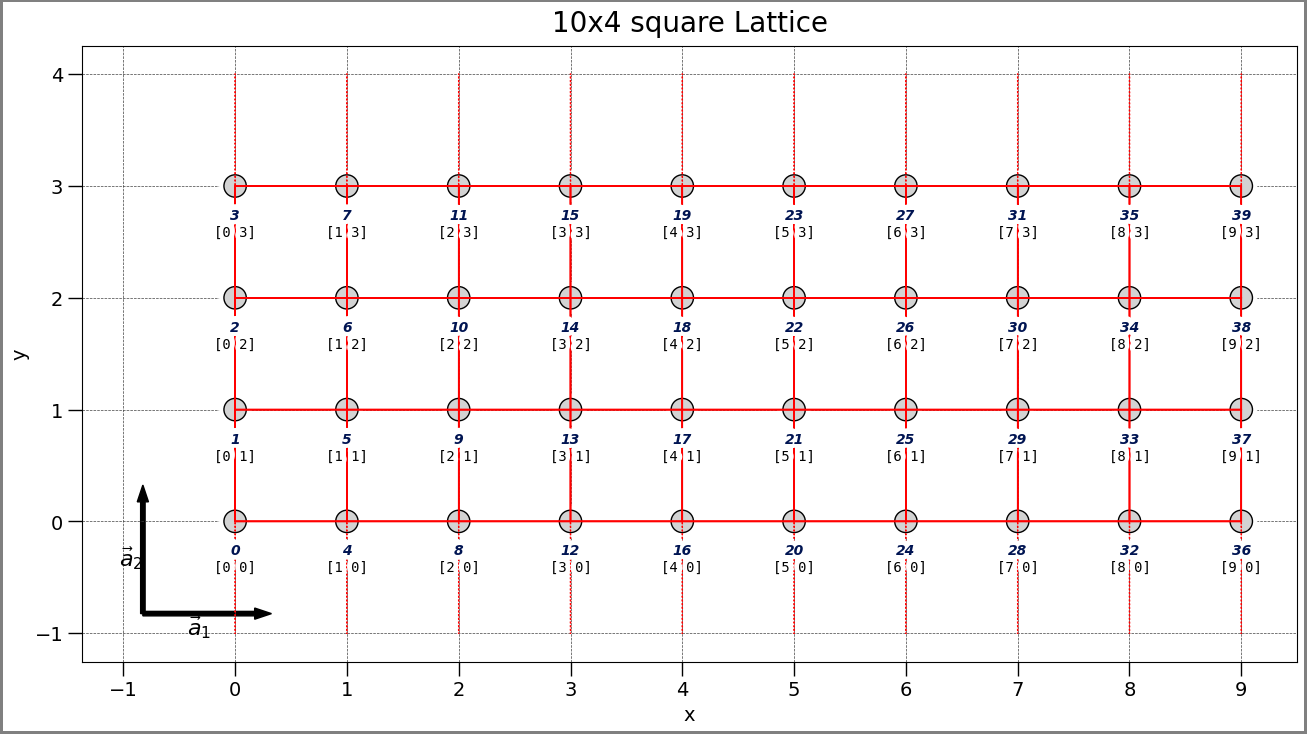

(<Figure size 2000x800 with 1 Axes>,
 <Axes: title={'center': '10x4 square Lattice'}, xlabel='x', ylabel='y'>)

In [ ]:
vis.plot_lattice(lattice)


The Hamiltonian will be simple,

$$
\begin{align}
H = H_t + H_U + H_{pin} \\
H_t = -t \sum_{\langle i j\rangle \sigma} c^\dagger_{i\sigma} c_{j\sigma} \\
H_U = U\sum_i n_{i\uparrow}n_{i\downarrow}\\
H_{pin} = \sum_{i\in \text{edge}} (-1)^{i_x+i_y} h_i S^z_i
\end{align}
$$

and we have a convenience function to add the edge pinning as well. We'll assume $t=1$, $h_i=0.5$ just like in the paper

In [ ]:
builder = ham.HamiltonianBuilder(
          lattice=lattice,
          spin_symm="collinear" # we have no spin-flip terms
              )
# add standard Hubbard terms
builder.nth_neighbor_hopping(1.0)
builder.onsite_hubbard(U)
builder.afm_pinning(0.5)
builder.finalize()

Using same twists for up and down spins
Building Hubbard U term with U=6.0
Building onsite hubbard with positive U values: 6.0
Using afm pin type: staggered
Combining terms of the same type
Combining tij terms
Combining Hubbard U, U1, and U2 terms where possible
Max spin symmetry is  2


In [ ]:
io.write_model_hamiltonian(builder.hamiltonian, "afqmc.h5",
                        nelec=nelec,spin_symm="collinear")

In [ ]:
# get a trial wavefunction: First, let's try a free-electron (i.e. non-interacting) wavefunction
from afqmctools.wavefunction.model import write_free_electron_wfn
write_free_electron_wfn(
    hamiltonian_fname="afqmc.h5",
    nelec=nelec
)

Generating a free-electron trial wavefunction
inlcuding component 0
Read in: [<Compressed Sparse Row sparse array of dtype 'complex128'
	with 320 stored elements and shape (80, 40)>]
Unique vals:
[-1.  +0.j -0.25+0.j  0.25+0.j]
using dense representation of 1-body Hamiltonian to find eigenvalues and orbitals
Eigenvalues of the non-interacting Hamiltonian:  [-3.91930234 -3.68372289 -3.31227316 -2.83491845 -2.29014608 -1.92078436
 -1.92078436 -1.72184903 -1.68819014 -1.68819014 -1.31813491 -1.31813491
 -1.17579002 -0.83837901 -0.83837901 -0.69597031 -0.32119227 -0.28764991
 -0.28764991 -0.0823666   0.0823666   0.28764991  0.28764991  0.32119227
  0.69597031  0.83837901  0.83837901  1.17579002  1.31813491  1.31813491
  1.68819014  1.68819014  1.72184903  1.92078436  1.92078436  2.29014608
  2.83491845  3.31227316  3.68372289  3.91930234]
using dense representation of 1-body Hamiltonian to find eigenvalues and orbitals
Eigenvalues of the non-interacting Hamiltonian:  [-3.91930234 -3.683722

/Users/keskridge/software/SAFIRE/build/safire_venv_py_3_13_3/lib/python3.13/site-packages/afqmctools/wavefunction/common.py:176: UserWarning: Using UHF Slater determinant for initial Walkers with a Collinear Trial Wavefunction. This can lead to very slow equilibration in AFQMC calculations. using ROHF Slater determinants for intiail Walkers is recommended.
  warn(


Now we'll write the file to run AFQMC. There are some better tools than this but let's hard code some things for now

In [ ]:
def getInputJson(series,wf_fname,h_fname=None):
    if h_fname is None:
        h_fname = wf_fname
    return f'''{{
  "afqmc": {{
    "project": {{
      "id": "qmc",
      "series": {series},
      "mixed_precision": false
    }},
    "execute": {{
      "walker_set": {{
        "walker_type": "COLLINEAR"
      }},
      "wavefunction": {{
        "filename": "{wf_fname}"
      }},
      "hamiltonian": {{
        "filename": "{h_fname}"
      }},
      "timestep": 0.005,
      "steps": 20000,
      "accumlate_interval": 2,
      "measure_interval": 2,
      "population_control_interval" : 2,
      "walker_ortho_interval" : 2,
      "n_walkers_per_mpi_task": 540,
      "estimator": {{
        "name": "energy",
        "overwrite": true,
        "print_components": true
      }},
      "estimator": {{
        "name":"back_propagation",
        "path_restoration":true,
        "extra_path_restoration":true,
        "bp_walker_ortho_interval":2,
        "nsteps":500,
        "naverages":1,
        "equil":2000,
        "onerdm" : {{
          "name":"onerdm"
	      }}
      }}
    }}
  }}
}}
'''

In [ ]:
print(getInputJson(0,"afqmc.h5"))

{
  "afqmc": {
    "project": {
      "id": "qmc",
      "series": 0,
      "mixed_precision": false
    },
    "execute": {
      "walker_set": {
        "walker_type": "COLLINEAR"
      },
      "wavefunction": {
        "filename": "afqmc.h5"
      },
      "hamiltonian": {
        "filename": "afqmc.h5"
      },
      "timestep": 0.005,
      "steps": 20000,
      "accumlate_interval": 2,
      "measure_interval": 2,
      "population_control_interval" : 2,
      "walker_ortho_interval" : 2,
      "n_walkers_per_mpi_task": 540,
      "estimator": {
        "name": "energy",
        "overwrite": true,
        "print_components": true
      },
      "estimator": {
        "name":"back_propagation",
        "path_restoration":true,
        "extra_path_restoration":true,
        "bp_walker_ortho_interval":2,
        "nsteps":500,
        "naverages":1,
        "equil":2000,
        "onerdm" : {
          "name":"onerdm"
	      }
      }
    }
  }
}



In [ ]:
with open("afqmc.json","w") as f:
    lines = getInputJson(0,"afqmc.h5")
    f.write(lines)

In [ ]:
!sbatch --wait run_afqmc.sh afqmc.json

/bin/bash: sbatch: command not found


In [ ]:
!mpirun -np 12 $AFQMC_EXEC afqmc.json

███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
This build has the following enabled:
 - MKL:  0
 - CUDA: 0
 - HIP:  0
app git branch: pre_beta
app git commit: f66a102cd77f593191f56b137e3b23ef6c361bee-dirty
app git commit date: Thu Sep 11 17:51:43 2025 -0400
app git commit subject: Tests: adds Closed Trial wavefunction cases for KP and THC Hamiltonians
 AFQMCFactory Project settings: 
    -- mixed_precision: false 
    -- ncores (local) : 1 
    -- n_groups       : 1 
    -- id             : qmc 
    -- series         : 0 
    -- MPI tasks/node : 12 
    -- MPI nodes      : 1 
    -- MPI tasks      : 12 


[warning] Unknown key: measure_interval
[warning] in Driver factory : Unknown input parameter(s) provided. Check the input file.

DrvFac::executeA

In [ ]:
!scalar_stats qmc.s000.scalar.dat -s time -t -e 10.0 --savefig energy_fe.png




====== [analyze_scalar_data Settings] ======

[+] fname            = qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = time            
[+] nequil           = 10.0            
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] ndiscard         = None            
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] verbose          = True            
[+] autocorr         = None            
[+] savefig          = energy_fe.png   
[+] dump_avail_columns = False           

AFQMC Energy   -38.852065 +/-   0.003468 46.14 10.0/100.0


<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/models/ex02_stripes/energy_fe.png" width="800px" />

### Analysis

We'll now analyze the spin density of the output given the free electron trial

In [ ]:
def staggeredSigns(Nx,Ny):
  signs = np.concatenate([(-1)**(np.arange(Nx)+1),(-1)**(np.arange(Nx))]*(Ny//2)).reshape(Ny,Nx).T.flatten()
  return -signs

def averageOverCols(Sz,Nx,Ny):
    return (Sz*staggeredSigns(*lattice.L)).reshape(*lattice_dims).mean(1)

In [ ]:
rho_avg, delta_rho = average_afqmc_rdm(rdm_file="qmc.s000.stat.h5")


In [ ]:
Xs,Ys,Zs = spobs.local_spin(np.vstack(rho_avg[0]),"collinear").real

delta_Sz = np.sqrt(delta_rho[0,0].diagonal()**2+delta_rho[0,1].diagonal()**2 )
# We're collinear
assert np.allclose(Xs,0)
assert np.allclose(Ys,0)

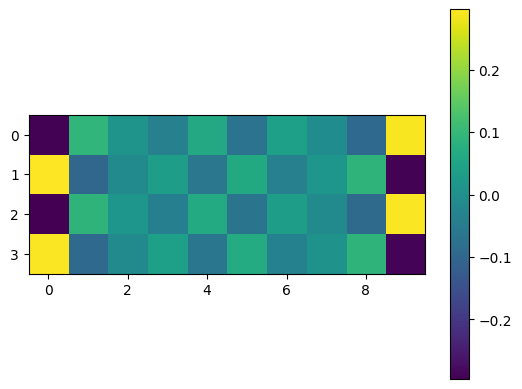

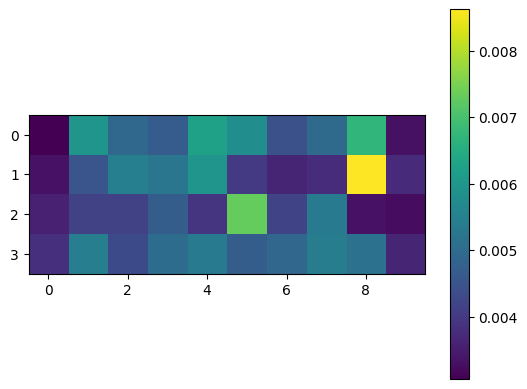

In [ ]:
plt.imshow(Zs.reshape(*lattice.L).T)
plt.colorbar()
plt.show()

plt.imshow(delta_Sz.reshape(*lattice.L).T)
plt.colorbar()
plt.show()

In [ ]:
# DMRG data of the form: site Sz Nup Ndn
SzDmrg = np.loadtxt("data_10x4_Ne16U6.0_15360.dat",usecols=(1,))


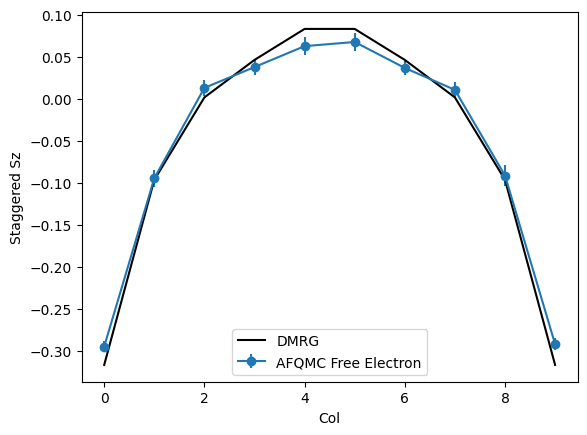

In [ ]:
# now we'll average over the columns

avg_delta_Sz = np.sqrt((delta_Sz.reshape(*lattice.L)**2).sum(1))

plt.errorbar(np.arange(lattice.L[0]),averageOverCols(Zs,*lattice.L),yerr=avg_delta_Sz,
             fmt='o-',label="AFQMC Free Electron")
plt.plot(-averageOverCols(SzDmrg,*lattice.L),label="DMRG",c='k')

plt.xlabel("Col")
plt.ylabel("Staggered Sz")
plt.legend()

# plt.ylim(-0.3,0.2)
plt.show()


# Self Consistency w/ Hartree-Fock

The idea behind self-consistent AFQMC is to have the trial wave function match as much as possible the output of AFQMC. [cite me]

For this model, we can do this by introducing an effective Hubbard model, where $U$ is replaced with $U_{eff}$. By solving Hartree-Fock (mean field theory) for this effective model and using the result as a trial wave function, we can scan through different $U_{eff}$ to find the one that matches the best.

We'll use AutoHF to explore creating a trial wave function for AFQMC. Let's do a few between $U_{eff}=1$ and $U_{eff}=4$

_Note:_ The Hartree-Fock code is faster if you use a GPU

In [ ]:
for Ueff in [1,2,3,4]:

    builder_eff = ham.HamiltonianBuilder(
              lattice=lattice,
              spin_symm="collinear"
                  )
    # add standard Hubbard terms
    builder_eff.nth_neighbor_hopping(1.0)
    builder_eff.onsite_hubbard(Ueff) # We want our HF solver to solve Ueff not U
    builder_eff.afm_pinning(0.5)
    builder_eff.finalize()

    # NOTICE: we must be careful here! We can either keep around afqmc.h5
    # which has the original Hamiltonian (U=6) and keep the wf and its hamiltonian together
    # or we have one file with afqmc_Ueff which has both the wf and builder.hamiltonian
    io.write_model_hamiltonian(builder_eff.hamiltonian, f"afqmc_{Ueff}.h5",
                            nelec=nelec,spin_symm="collinear")

    hf_settings = dict(
        numSteps = 2000,
        output = f"afqmc_{Ueff}.h5", # change file name!
        opt_method="lbfgs",
        ansatz="SD_ROT",
        nelec = nelec,
        numTrials = 8,
        seed = 1,
        noncollinear = False
    )
    data = autohf.solver.lattice_hf(
        hamiltonian=builder_eff.hamiltonian,
        lattice=lattice,
        settings=hf_settings,
    )
    print(data["E_final"])

    with open(f"afqmc_{Ueff}.json","w") as f:
        lines = getInputJson(Ueff,f"afqmc_{Ueff}.h5","afqmc.h5")
        f.write(lines)
    print(f"Written {Ueff}")

Using same twists for up and down spins
Building Hubbard U term with U=1
Building onsite hubbard with positive U values: 1
Using afm pin type: staggered
Combining terms of the same type
Combining tij terms
Combining Hubbard U, U1, and U2 terms where possible
Max spin symmetry is  2

    -----------------------
    - ╔═╗ ------- ╖ ╓╔═╕ --
    - ╠═╣ ╖╖╒╦╕╔╗ ╠═╣╠╕ ---
    - ╜ ╙ ╚╝ ╜ ╚╝ ╜ ╙╨ ----
    -----------------------
    

 ===== AutoHF Settings ===== 

        noncollinear                                            False
        gpu                                                     False
        approx_expm                                             False
        force_complex                                           False
        ansatz                                                 SD_ROT
        opt_method                                              lbfgs
        riemannian                                              False
        seed                                     

AttributeError: 'Hamiltonian' object has no attribute 'Nbands'

In [ ]:
for Ueff in [1,2,3,4]:
    !sbatch --wait run_afqmc.sh afqmc_{Ueff}.json

In [ ]:
rhos, deltas = [],[]

for Ueff in [0,1,2,3,4]:
    rho_avg, delta_rho = average_afqmc_rdm(rdm_file=f"qmc.s00{Ueff}.stat.h5")
    rhos.append(rho_avg)
    deltas.append(delta_rho)

In [ ]:
for Ueff,rho_avg,delta_rho in zip([0,1,2,3,4],rhos,deltas):
    Xs,Ys,Zs = spobs.local_spin(np.vstack(rho_avg[0]),"collinear").real

    delta_Sz = np.sqrt(delta_rho[0,0].diagonal()**2+delta_rho[0,1].diagonal()**2 )
    # We're collinear
    assert np.allclose(Xs,0)
    assert np.allclose(Ys,0)

    fig,axes = plt.subplots(1,2,figsize=(12,4))
    p = axes[0].matshow(Zs.reshape(*lattice.L).T)
    plt.colorbar(p,ax= axes[0])


    p =axes[1].matshow(delta_Sz.reshape(*lattice.L).T)
    plt.colorbar(p,ax= axes[1])
    if Ueff==0:
        fig.suptitle(f"Free Electron")
    else:
        fig.suptitle(f"{Ueff=}")
    plt.show()

In [ ]:
# now we'll average over the columns

for Ueff,rho_avg,delta_rho in zip([0,1,2,3,4],rhos,deltas):
    Xs,Ys,Zs = spobs.local_spin(np.vstack(rho_avg[0]),"collinear").real

    delta_Sz = np.sqrt(delta_rho[0,0].diagonal()**2+delta_rho[0,1].diagonal()**2 )
    avg_delta_Sz = np.sqrt((delta_Sz.reshape(*lattice.L)**2).sum(1))
    if Ueff==0:
        label = "AFQMC Free Electron"
    else:
        label = f"AFQMC W/ HF Ueff={Ueff}"
    plt.errorbar(np.arange(lattice.L[0]),averageOverCols(Zs,*lattice.L),yerr=avg_delta_Sz,
                 fmt='o-',label=label)
plt.plot(-averageOverCols(SzDmrg,*lattice.L),'x-',label="DMRG",c='k')

plt.xlabel("Col")
plt.ylabel("Staggered Sz")
plt.legend()

# plt.ylim(-0.3,0.2)
plt.show()


## Self-Consistent Condition

We'll now measure the error between the trial wave function's observable and the output from AFQMC

In [ ]:
trial_rhos = []
for Ueff in Ueffs:
    if Ueff==0:
        fname = "afqmc.h5"
    else:
        fname = f"afqmc_{Ueff}.h5"
    (coeffs,wfn), psi0, (na, nb),spintype = read_wavefunction(fname)
    # We assume spin balance below
    o = wfn.reshape(lattice.N_sites,na,2,order='F').real
    o = np.stack([o[:,:,0],o[:,:,1]])

    rdm = greens_1body(o)
    trial_rhos.append(rdm)

In [ ]:
# now we'll average over the columns
Ueffs = [0,1,2,3,4]
for Ueff,trial_rho in zip(Ueffs,trial_rhos):
    Xs,Ys,Zs = spobs.local_spin(np.vstack(trial_rho),"collinear").real


    avg_delta_Sz = np.sqrt((delta_Sz.reshape(*lattice.L)**2).sum(1))
    if Ueff==0:
        label = "Free Electron"
    else:
        label = f"HF W/ HF Ueff={Ueff}"
    plt.errorbar(np.arange(lattice.L[0]),
                 averageOverCols(Zs,*lattice.L),yerr=avg_delta_Sz,
                 fmt='o--',label=label)
plt.plot(-averageOverCols(SzDmrg,*lattice.L),'x-',label="DMRG",c='k')

plt.xlabel("Col")
plt.ylabel("Staggered Sz")
plt.legend()

# plt.ylim(-0.3,0.2)
plt.show()


In [ ]:
Ueffs = [0,1,2,3,4]

dmrg_sz = -averageOverCols(SzDmrg,*lattice.L)

xs,ys,yerrs = [],[],[]
for Ueff,rho_avg,delta_rho,trial_rho in zip(Ueffs,rhos,deltas,trial_rhos):
    XsT,YsT,ZsT = spobs.local_spin(np.vstack(trial_rho),"collinear").real
    Xs,Ys,Zs = spobs.local_spin(np.vstack(rho_avg[0]),"collinear").real

    afqmc_sz = averageOverCols(Zs,*lattice.L)
    trial_sz = averageOverCols(ZsT,*lattice.L)


    delta_Sz = np.sqrt(delta_rho[0,0].diagonal()**2+delta_rho[0,1].diagonal()**2 )
    avg_delta_Sz = np.sqrt((delta_Sz.reshape(*lattice.L)**2).sum(1))

    xs.append(Ueff)
    ys.append(np.mean(np.abs(afqmc_sz-dmrg_sz)))
    yerrs.append(np.mean(avg_delta_Sz**2))

plt.errorbar(xs,ys,yerr=yerrs,fmt='o-',label="AFQMC",capsize=6)
plt.xticks(Ueffs)
plt.xlabel("Ueff")
plt.ylabel(r"$\langle |$DMRG $S_z - $AFQMC $S_z|\rangle$",fontsize=12)
plt.legend()
plt.grid()

# plt.ylim(-0.3,0.2)
plt.show()


xs,ys,yerrs = [],[],[]
for Ueff,rho_avg,delta_rho,trial_rho in zip(Ueffs,rhos,deltas,trial_rhos):
    XsT,YsT,ZsT = spobs.local_spin(np.vstack(trial_rho),"collinear").real
    Xs,Ys,Zs = spobs.local_spin(np.vstack(rho_avg[0]),"collinear").real

    afqmc_sz = averageOverCols(Zs,*lattice.L)
    trial_sz = averageOverCols(ZsT,*lattice.L)


    delta_Sz = np.sqrt(delta_rho[0,0].diagonal()**2+delta_rho[0,1].diagonal()**2 )
    avg_delta_Sz = np.sqrt((delta_Sz.reshape(*lattice.L)**2).sum(1))

    xs.append(Ueff)
    ys.append(np.mean(np.abs(afqmc_sz-trial_sz)))
    yerrs.append(np.mean(avg_delta_Sz**2))

plt.errorbar(xs,ys,yerr=yerrs,fmt='o-',label="AFQMC",capsize=6)
plt.xticks(Ueffs)
plt.xlabel("Ueff")
plt.ylabel(r"$\langle |$Trial $S_z - $AFQMC $S_z|\rangle$",fontsize=12)
plt.legend()
plt.grid()

# plt.ylim(-0.3,0.2)
plt.show()


So we can see that somewhere around $U_{eff}\approx 3$
would have the lowest error for self consistency.
Despite the difference between DMRG and AFQMC being on average 0.01, there is a clear optimal trial wave function to use. For fine tuning between $U_{eff}\in [2,4]$, we'll need more sophisticated methods than presented here.

In our original study, we found the optimal $U_{eff} \approx 2.77$

# Your Turn Part 1 - Recreate Fig 1

<div>
    <img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/models/ex02_stripes/fig1.png" width="300px" />
</div>

Let's recreate figure 1 from Xu et al, by changing

- 10x4 -> 20x4
- Doping 0.2 to 0.1 hole doping
- U=6 ✓

# Your Turn Part 2

Lets use this as a test bed to explore how AFQMC responds to different settings. Some questions to consider

- Use $U_{eff} = U$ or the "bare U" Hartree-Fock trial. How does the quality of the results change?
- We compared spin densities, what about hole density? This is the effectively the same as comparing charge density.
- Use a trial with a small number of steps so that the solver doesn't converge. How do the results change? How could you tell this trial isn't good?
- The free electron trial isn't a valid RHF state (why?). What would be the corresponding RHF solution? What does that output look like?
- Explore the parameters of backpropagation, how does the 1rdm change as a function of `nsteps`? you can include `naverages` to see the results converge